# 1. Création et Chargement du Dataset Final
Dans cette section, nous combinons les données Gold et Silver (nettoyées et au même format) pour constituer le `dataset_final.csv`.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuration
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# Chemins des 4 fichiers finaux générés
gold_1_path = 'group_1/deliverables/gold_shard_1_final.csv'
silver_1_path = 'group_1/deliverables/silver_shard_1_final.csv'
gold_2_path = 'group_2/deliverables/gold_shard_2_final.csv'
silver_2_path = 'group_2/deliverables/silver_shard_2_final.csv'

# Chargement
df_gold_1 = pd.read_csv(gold_1_path)
df_silver_1 = pd.read_csv(silver_1_path)
df_gold_2 = pd.read_csv(gold_2_path)
df_silver_2 = pd.read_csv(silver_2_path)

# Identification du shard d'origine
df_gold_1['shard'] = 'shard_1'
df_silver_1['shard'] = 'shard_1'
df_gold_2['shard'] = 'shard_2'
df_silver_2['shard'] = 'shard_2'

# Fusion pour le dataset final
df_final = pd.concat([df_gold_1, df_silver_1, df_gold_2, df_silver_2], ignore_index=True)

# Sauvegarde du dataset final
df_final.to_csv('dataset_final.csv', index=False)
print("Fichier sauvegardé : dataset_final.csv\n")

print(f"Group 1 - Gold: {len(df_gold_1)} lignes, Silver: {len(df_silver_1)} lignes")
print(f"Group 2 - Gold: {len(df_gold_2)} lignes, Silver: {len(df_silver_2)} lignes")
print(f"Dataset Final créé avec succès : {len(df_final)} lignes")
display(df_final.head(3))

Fichier sauvegardé : dataset_final.csv

Group 1 - Gold: 1000 lignes, Silver: 9005 lignes
Group 2 - Gold: 1003 lignes, Silver: 9005 lignes
Dataset Final créé avec succès : 20013 lignes


,data_id,id,classe,darija_arabic,darija_arabizi,english,modern_standard_arabic,status,dataset_type,shard
0,data50034,WIKI_C_10914,C,— — (1988)، عيش الحياة الزوينة، سالت لايك سيتي...,"— — (1988), 3ish l7ayat zwina, Salt Lake City,...",— — (1988). Live the Good Life. Salt Lake City...,— — (١٩٨٨)، عش الحياة الطيبة، سولت ليك سيتي، ي...,VALIDATED,GOLD,shard_1
1,data50035,WIKI_C_03079,C,بطّاطا من غير شي ثابت تقادِي عام، الكومبا ديال...,"Bettata men ghir chi thabit ta9adi 3am, l-comb...","Up to a multiplicative constant, the Dirac com...",باستثناء ثابتٍ عامٍ ضربي، فإن مشط ديراك يساوي ...,VALIDATED,GOLD,shard_1
2,data50036,WIKI_C_04973,C,ف 1940، ميريلاند و لباطويات لاخرين ديال الحرب ...,"f 1940, maryland w l batwiyat l akhrin dyal l7...","In 1940 , Maryland and the other battleships o...",في عام 1940، غيرت ميريلاند وسفن المعركة الأخرى...,VALIDATED,GOLD,shard_1


# 2. Analyse des Données et Statistiques de Base
Vérification valeurs manquantes et distribution des classes pour le Dataset Final (conformément au guide).

Valeurs manquantes par colonne dans le Dataset Final :
data_id                   0
id                        0
classe                    0
darija_arabic             0
darija_arabizi            0
english                   0
modern_standard_arabic    0
status                    0
dataset_type              0
shard                     0
dtype: int64

Nombre de doublons sur data_id : 3

Répartition des statuts :
status
VALIDATED    20013
Name: count, dtype: int64

[OK] Tous les statuts sont validés !

Répartition des classes :
 classe
C    5108
A    5056
B    4957
D    4892
Name: count, dtype: int64


C:\Users\X1\AppData\Local\Temp\ipykernel_25616\885538882.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_final, x='classe', order=class_counts.index, palette='viridis')


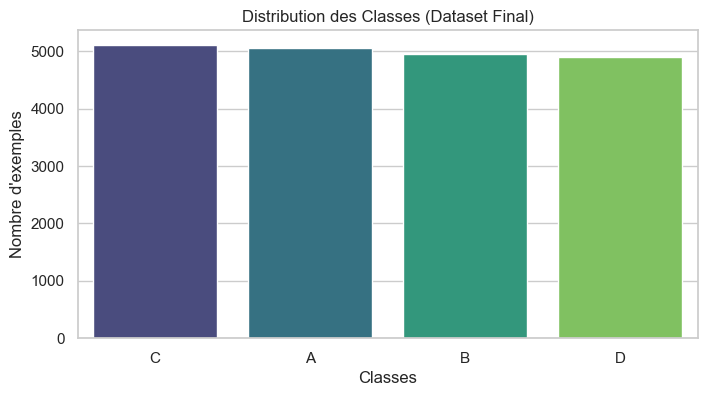

In [13]:
print("Valeurs manquantes par colonne dans le Dataset Final :")
print(df_final.isna().sum())

print(f"\nNombre de doublons sur data_id : {df_final.duplicated(subset=['data_id']).sum()}")

# Vérification des statuts
print("\nRépartition des statuts :")
if 'status' in df_final.columns:
    status_counts = df_final['status'].value_counts(dropna=False)
    print(status_counts)
    
    non_validated = df_final[~df_final['status'].astype(str).str.lower().isin(['validated', 'approved', 'completed'])]
    if len(non_validated) > 0:
        print(f"\n[WARNING] {len(non_validated)} lignes n'ont pas un statut validé.")
    else:
        print("\n[OK] Tous les statuts sont validés !")
else:
    print("La colonne 'status' n'existe pas dans le dataset.")

# Distribution des classes
class_counts = df_final['classe'].value_counts()
print("\nRépartition des classes :\n", class_counts)

# Visualisation (Classes)
plt.figure(figsize=(8, 4))
sns.countplot(data=df_final, x='classe', order=class_counts.index, palette='viridis')
plt.title('Distribution des Classes (Dataset Final)')
plt.ylabel('Nombre d\'exemples')
plt.xlabel('Classes')
plt.show()


# 4. Statistiques de Longueur des Textes
la distribution des longueurs confirme l'homogénéité du Dataset Final.

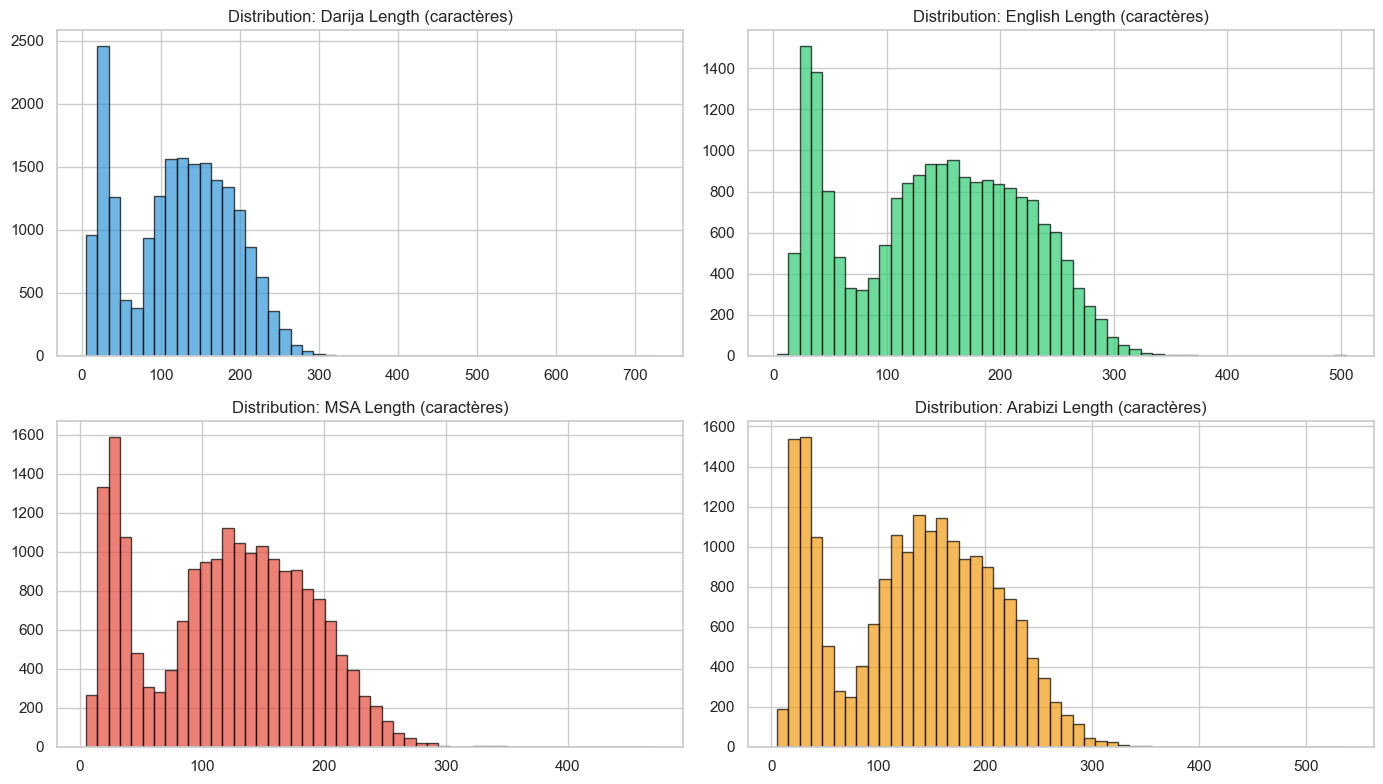

In [14]:
# Ajout des colonnes de longueur
df_final['darija_len'] = df_final['darija_arabic'].fillna('').str.len()
df_final['english_len'] = df_final['english'].fillna('').str.len()
df_final['msa_len'] = df_final['modern_standard_arabic'].fillna('').str.len()
df_final['arabizi_len'] = df_final['darija_arabizi'].fillna('').str.len()

# Visualisation des longueurs (4 graphiques)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].hist(df_final['darija_len'].dropna(), bins=50, color='#3498db', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Distribution: Darija Length (caractères)')

axes[0, 1].hist(df_final['english_len'].dropna(), bins=50, color='#2ecc71', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Distribution: English Length (caractères)')

axes[1, 0].hist(df_final['msa_len'].dropna(), bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Distribution: MSA Length (caractères)')

axes[1, 1].hist(df_final['arabizi_len'].dropna(), bins=50, color='#f39c12', alpha=0.7, edgecolor='black')
axes[1, 1].set_title('Distribution: Arabizi Length (caractères)')

plt.tight_layout()
plt.show()

# 5. Vérification Finale de la Qualité (Anomalies)
Vérification des erreurs de script (ex: caractères arabes en anglais) et des champs vides sur le dataset final pour s'assurer qu'aucune régression n'est passée.

In [15]:
import re

print("VÉRIFICATION FINALE DES ANOMALIES (Dataset Final)")
print("=" * 80)

arabic_pattern = re.compile(r'[؀-ۿ]')

# Détection des Anomalies communes
empty_english = (df_final['english'].fillna('').str.len() == 0).sum()
empty_msa = (df_final['modern_standard_arabic'].fillna('').str.len() == 0).sum()
empty_darija = (df_final['darija_arabic'].fillna('').str.len() == 0).sum()
empty_arabizi = (df_final['darija_arabizi'].fillna('').str.len() == 0).sum()

doublons = df_final.duplicated(subset=['data_id']).sum() if 'data_id' in df_final.columns else 0

print(f"Doublons (sur data_id) : {doublons} cas")
print(f"Traductions Darija manquantes : {empty_darija} cas")
print(f"Traductions English manquantes : {empty_english} cas")
print(f"Traductions MSA manquantes : {empty_msa} cas")
print(f"Traductions Arabizi manquantes : {empty_arabizi} cas")

print("=" * 80)
if empty_english == 0 and empty_msa == 0 and empty_darija == 0 and empty_arabizi == 0 and doublons == 0:
    print("[OK] Dataset final propre, aucune anomalie critique détectée !")
else:
    print("[WARNING] Des anomalies sont encore présentes dans le dataset final et peuvent nécessiter un dernier nettoyage.")

VÉRIFICATION FINALE DES ANOMALIES (Dataset Final)
Doublons (sur data_id) : 3 cas
Traductions Darija manquantes : 0 cas
Traductions English manquantes : 0 cas
Traductions MSA manquantes : 0 cas
Traductions Arabizi manquantes : 0 cas
[WARNING] Des anomalies sont encore présentes dans le dataset final et peuvent nécessiter un dernier nettoyage.


# 6. Visualisation des Anomalies
la distribution d'éventuelles erreurs restantes sur le Dataset Final.


ANOMALY VISUALIZATION


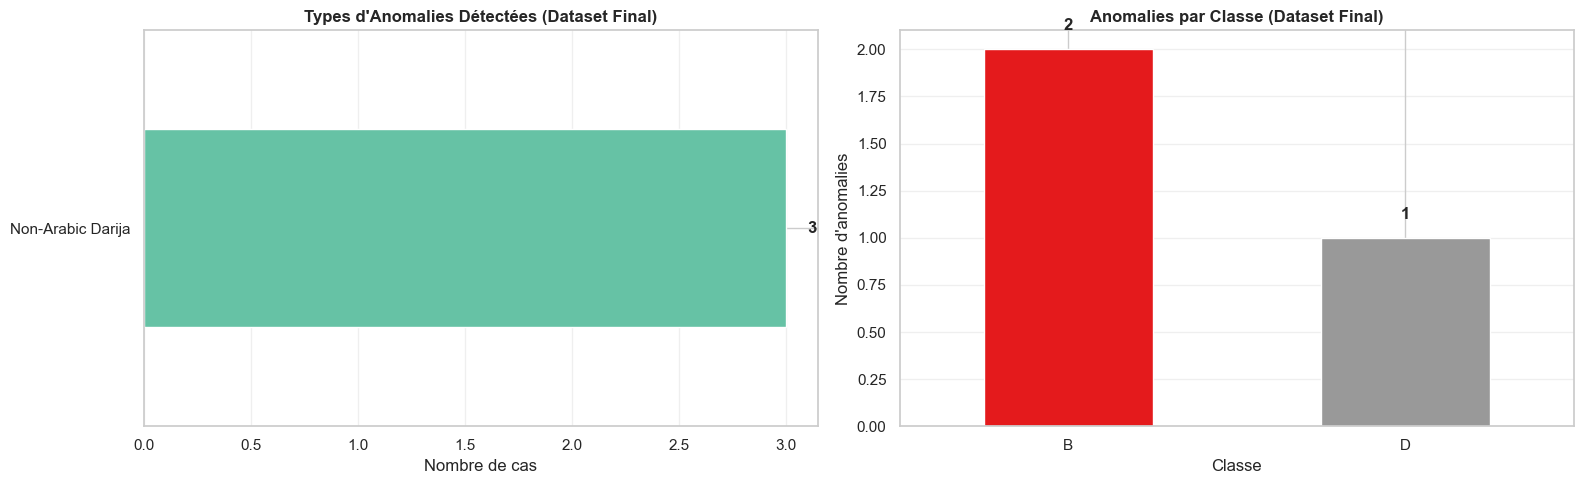


PROBLEMATIC ENTRIES (3 rows):


,Issues,ID,Classe,Status,dataset type,shard
0,Non-Arabic Darija,DATA_21312,B,VALIDATED,GOLD,shard_2
1,Non-Arabic Darija,WIKI_D_05207,D,VALIDATED,GOLD,shard_2
2,Non-Arabic Darija,DATA_14117,B,VALIDATED,GOLD,shard_2


In [16]:
print("\nANOMALY VISUALIZATION")

# Collecter récursivement les problèmes pour le dataset final
issues_data = []
for idx, row in df_final.iterrows():
    issues = []
    
    # Check for Arabic in Arabizi
    arabizi = str(row.get('darija_arabizi', ''))
    if arabizi and arabic_pattern.search(arabizi):
        issues.append('Arabic in Arabizi')
    
    # Check for non-Arabic Darija
    darija = str(row.get('darija_arabic', ''))
    if darija and len(darija) > 0 and not arabic_pattern.search(darija):
        issues.append('Non-Arabic Darija')
    
    # Check for Arabic in English
    eng = str(row.get('english', ''))
    if eng and arabic_pattern.search(eng):
        issues.append('Arabic in English')
    
    # Check for empty translations
    if len(darija.strip()) == 0:
        issues.append('Empty Darija')
    if len(eng.strip()) == 0:
        issues.append('Empty English')
    
    msa = str(row.get('modern_standard_arabic', ''))
    if len(msa.strip()) == 0:
        issues.append('Empty MSA')
    
    if issues:
        issues_data.append({
            'Issues': ', '.join(issues),
            'ID': row['id'],
            'Classe': row['classe'],
            'Status': row['status'],
            'dataset type': row['dataset_type'],
            'shard': row['shard']
        })

issues_df = pd.DataFrame(issues_data)

if len(issues_df) > 0:
    # Count issue types
    all_issues = []
    for issue_str in issues_df['Issues']:
        all_issues.extend([i.strip() for i in issue_str.split(',')])
    
    issue_counts = pd.Series(all_issues).value_counts()
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Issue counts bar chart
    colors_issues = plt.cm.Set2(np.linspace(0, 1, max(1, len(issue_counts))))
    issue_counts.plot(kind='barh', ax=axes[0], color=colors_issues)
    axes[0].set_title('Types d\'Anomalies Détectées (Dataset Final)', fontweight='bold', fontsize=12)
    axes[0].set_xlabel('Nombre de cas')
    axes[0].grid(axis='x', alpha=0.3)
    
    for i, v in enumerate(issue_counts.values):
        axes[0].text(v + 0.1, i, str(v), va='center', fontweight='bold')
    
    # Distribution by class
    class_issues = issues_df['Classe'].value_counts()
    colors_class = plt.cm.Set1(np.linspace(0, 1, max(1, len(class_issues))))
    class_issues.plot(kind='bar', ax=axes[1], color=colors_class)
    axes[1].set_title('Anomalies par Classe (Dataset Final)', fontweight='bold', fontsize=12)
    axes[1].set_xlabel('Classe')
    axes[1].set_ylabel('Nombre d\'anomalies')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
    axes[1].grid(axis='y', alpha=0.3)
    
    for i, v in enumerate(class_issues.values):
        axes[1].text(i, v + 0.1, str(v), ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Display problematic rows table
    print(f"\nPROBLEMATIC ENTRIES ({len(issues_df)} rows):")
    print("=" * 120)
    display(issues_df)
else:
    print("\n[OK] NO ISSUES DETECTED IN THE FINAL DATASET!")
